In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.db import get_engine, get_training_data

# Load data from PostgreSQL
engine = get_engine()
df = get_training_data(engine)

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (7043, 21)

Column types:
customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure_months          int64
phone_service         object
internet_service      object
contract_type         object
paperless_billing     object
monthly_charges      float64
total_charges        float64
payment_method        object
multiple_lines        object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
target                 int64
dtype: object

First 3 rows:


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract_type,paperless_billing,...,total_charges,payment_method,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,target
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,Yes,...,29.85,Electronic check,No phone service,No,Yes,No,No,No,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,No,...,1889.50,Mailed check,No,Yes,No,Yes,No,No,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,Yes,...,108.15,Mailed check,No,Yes,Yes,No,No,No,No,1


In [2]:
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Target Distribution ===")
print(df['target'].value_counts())
print(f"\nChurn rate: {df['target'].mean()*100:.1f}%")

print("\n=== Numeric Features Summary ===")
df[['tenure_months','monthly_charges','total_charges']].describe().round(2)

=== Missing Values ===
total_charges    11
dtype: int64

=== Target Distribution ===
target
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%

=== Numeric Features Summary ===


,tenure_months,monthly_charges,total_charges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


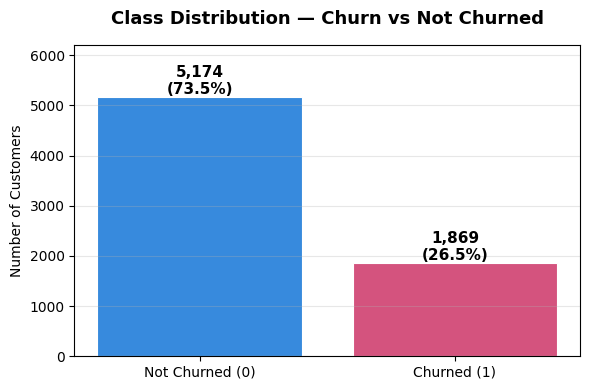

Class imbalance ratio: 2.8:1


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts()
bars = ax.bar(['Not Churned (0)', 'Churned (1)'],
              counts.values,
              color=['#378ADD', '#D4537E'],
              edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution — Churn vs Not Churned',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {counts[0]/counts[1]:.1f}:1")

C:\Users\SAYAN\AppData\Local\Temp\ipykernel_40148\3057195109.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Churn', y='tenure_months',


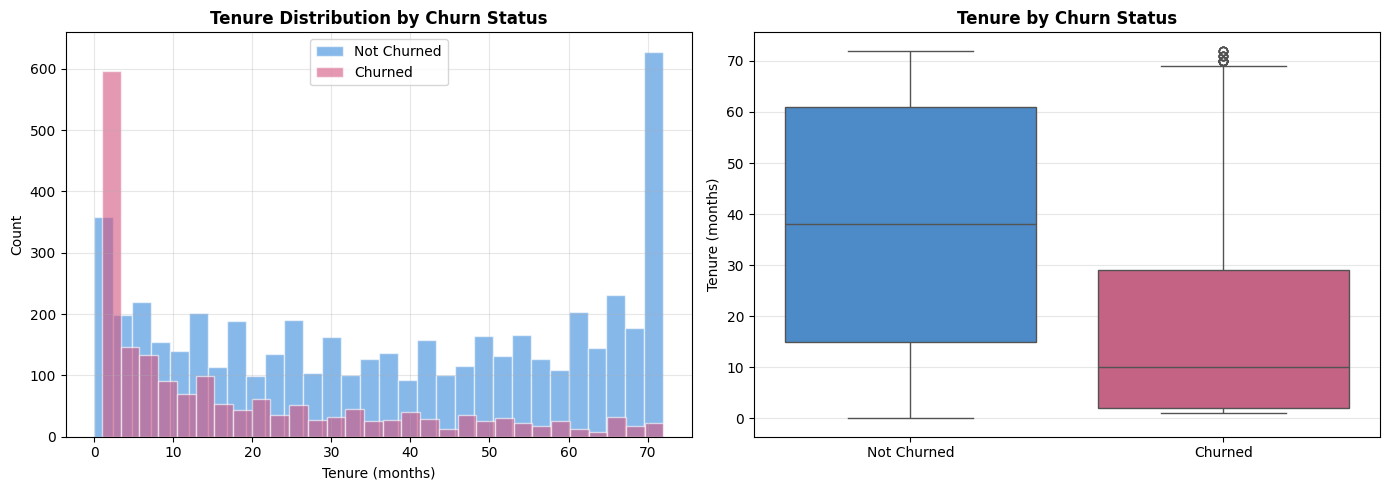

Avg tenure - Not Churned: 37.6 months
Avg tenure - Churned:     18.0 months


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of tenure by churn status
for churn_val, color, label in [(0, '#378ADD', 'Not Churned'),
                                  (1, '#D4537E', 'Churned')]:
    axes[0].hist(df[df['target']==churn_val]['tenure_months'],
                 bins=30, alpha=0.6, color=color,
                 label=label, edgecolor='white')

axes[0].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
df_plot = df.copy()
df_plot['Churn'] = df_plot['target'].map({0: 'Not Churned', 1: 'Churned'})
sns.boxplot(data=df_plot, x='Churn', y='tenure_months',
            palette={'Not Churned': '#378ADD', 'Churned': '#D4537E'},
            ax=axes[1])
axes[1].set_title('Tenure by Churn Status', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Tenure (months)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/tenure_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg tenure - Not Churned: {df[df['target']==0]['tenure_months'].mean():.1f} months")
print(f"Avg tenure - Churned:     {df[df['target']==1]['tenure_months'].mean():.1f} months")

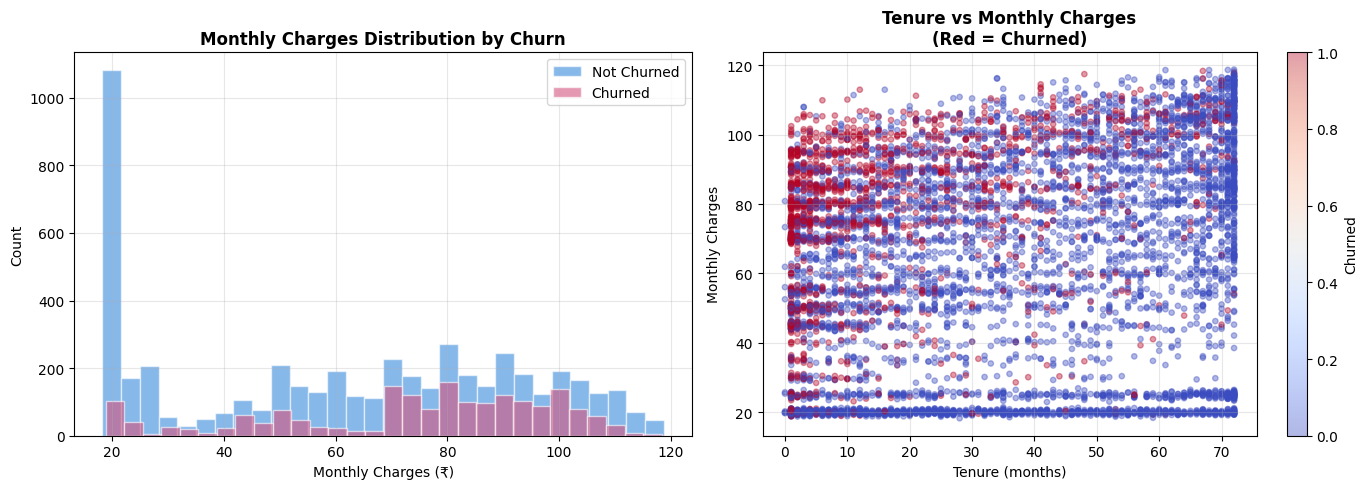

Avg monthly charges - Not Churned: $61.27
Avg monthly charges - Churned:     $74.44


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
for churn_val, color, label in [(0, '#378ADD', 'Not Churned'),
                                  (1, '#D4537E', 'Churned')]:
    axes[0].hist(df[df['target']==churn_val]['monthly_charges'],
                 bins=30, alpha=0.6, color=color,
                 label=label, edgecolor='white')

axes[0].set_title('Monthly Charges Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Monthly Charges (₹)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter: tenure vs monthly charges coloured by churn
scatter = axes[1].scatter(df['tenure_months'],
                           df['monthly_charges'],
                           c=df['target'],
                           cmap='coolwarm',
                           alpha=0.4, s=15)
axes[1].set_title('Tenure vs Monthly Charges\n(Red = Churned)',
                   fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Churned')

plt.tight_layout()
plt.savefig('../data/processed/charges_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg monthly charges - Not Churned: ${df[df['target']==0]['monthly_charges'].mean():.2f}")
print(f"Avg monthly charges - Churned:     ${df[df['target']==1]['monthly_charges'].mean():.2f}")

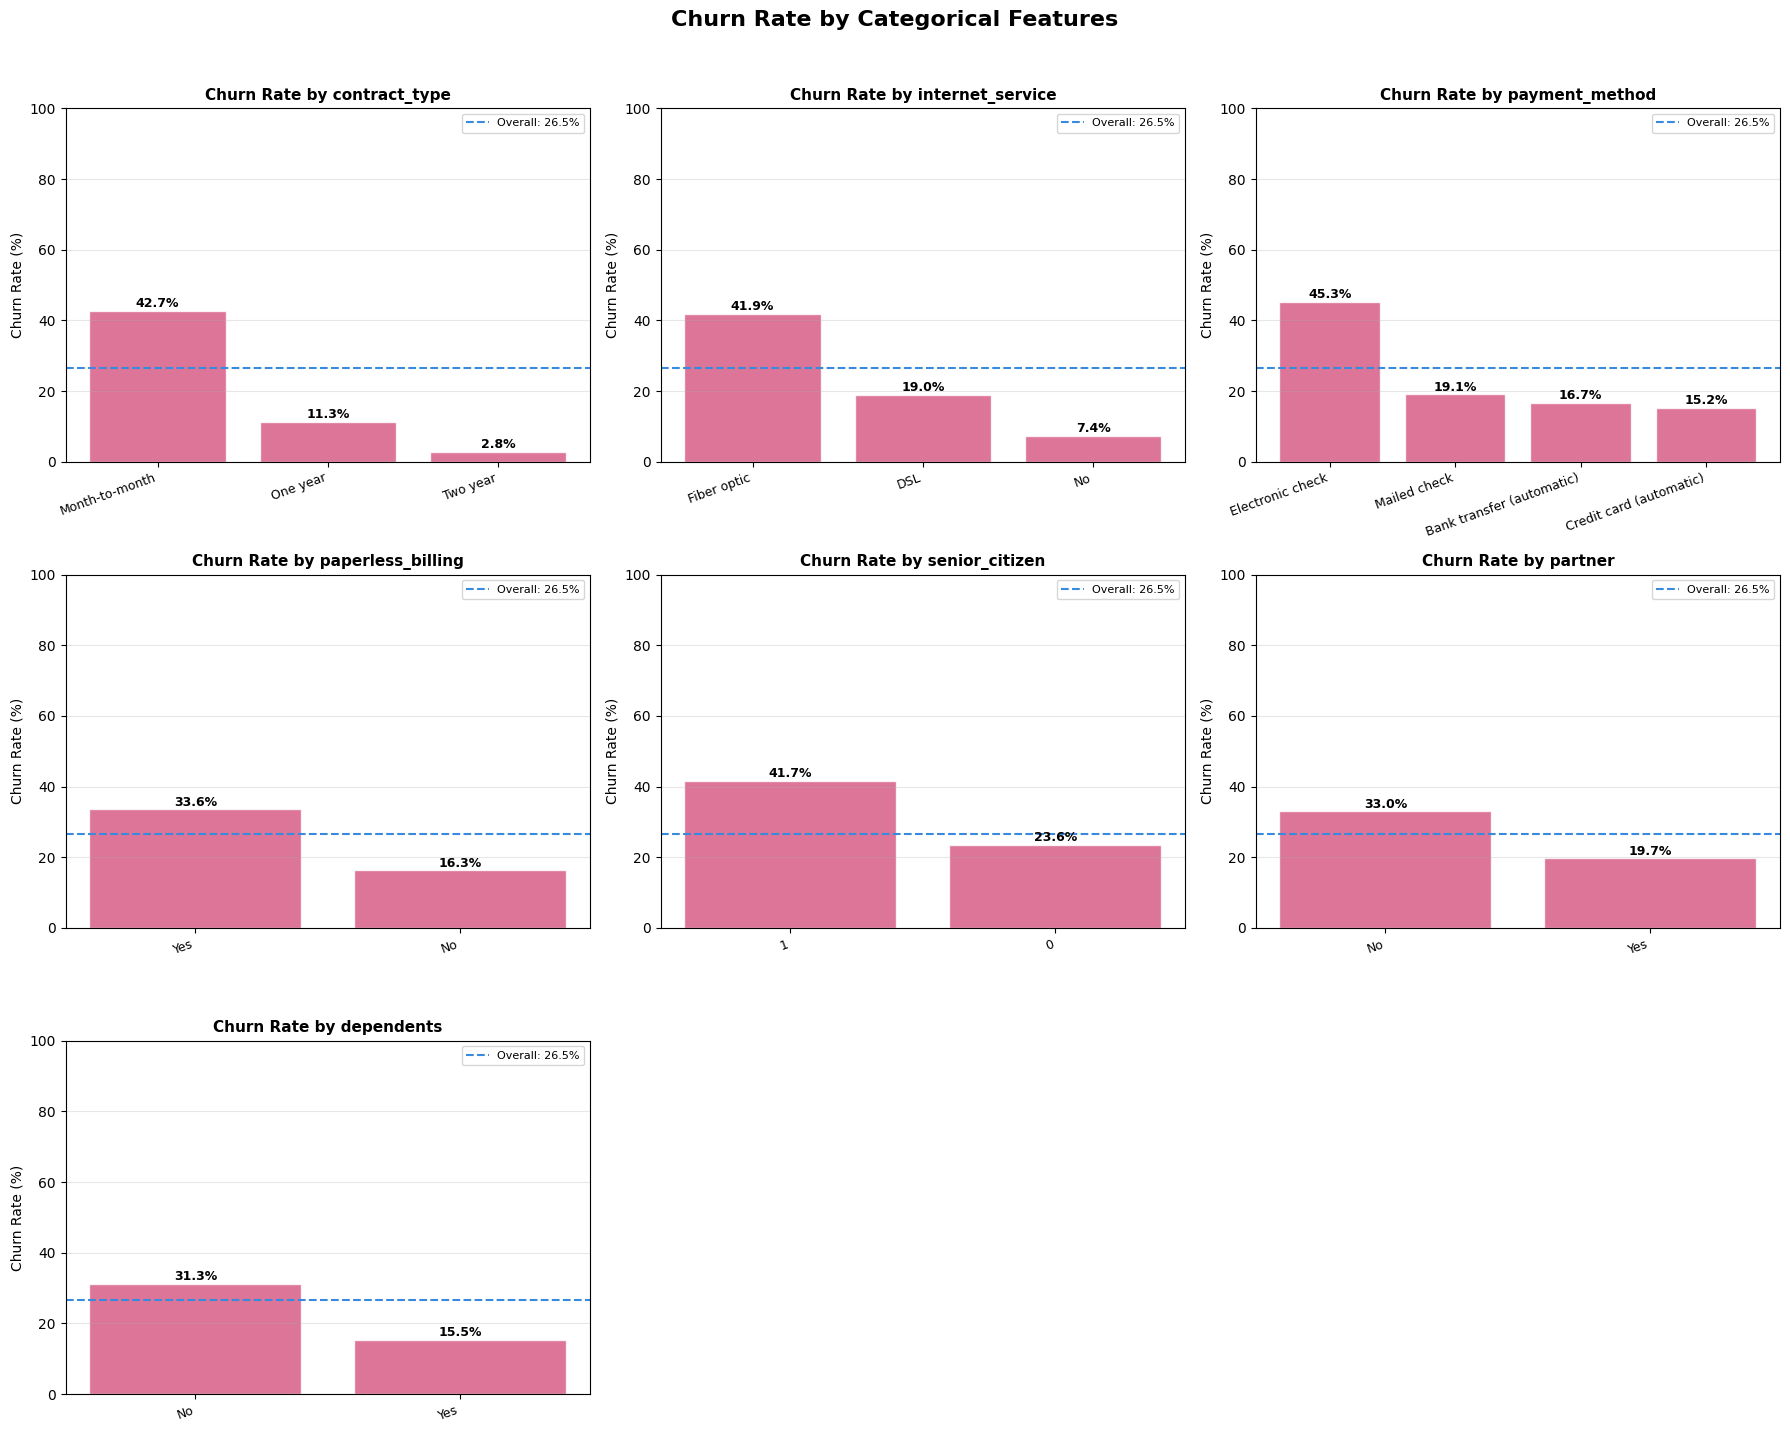

In [6]:
cat_features = ['contract_type', 'internet_service',
                'payment_method', 'paperless_billing',
                'senior_citizen', 'partner', 'dependents']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['target'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)

    bars = axes[i].bar(range(len(churn_rate)),
                        churn_rate.values,
                        color='#D4537E', alpha=0.8, edgecolor='white')

    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index,
                             rotation=20, ha='right', fontsize=9)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 100)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].axhline(y=df['target'].mean()*100,
                     color='#378ADD', linestyle='--',
                     linewidth=1.5, label=f'Overall: {df["target"].mean()*100:.1f}%')
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 1,
                      f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Hide unused subplots
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/churn_by_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()

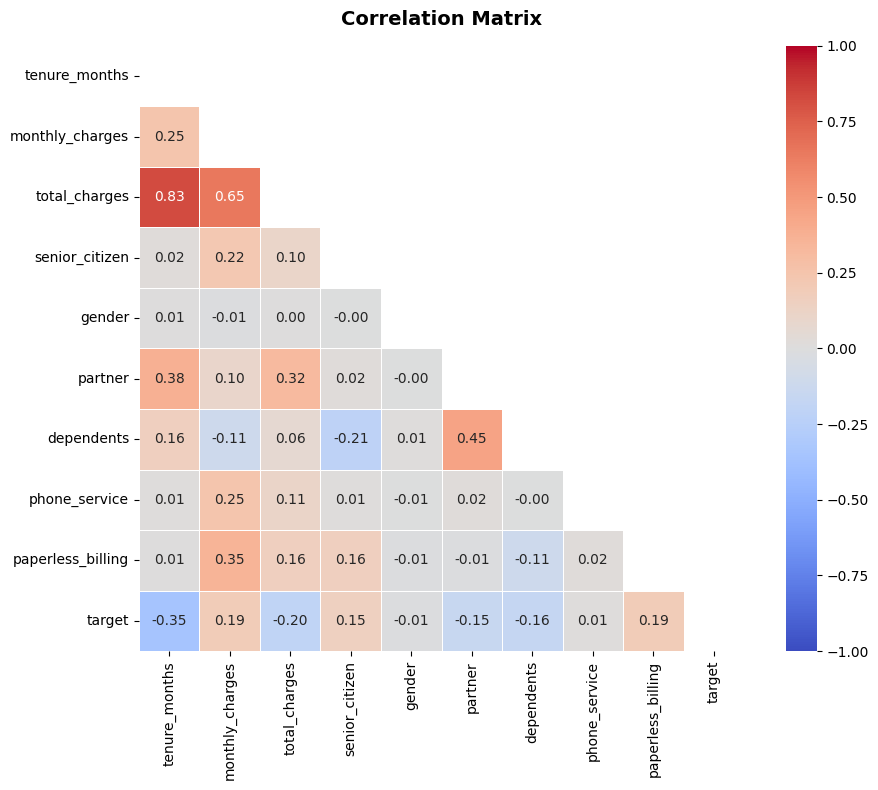

In [7]:
# Encode binary categoricals for correlation
df_corr = df.copy()

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['gender', 'partner', 'dependents', 'phone_service', 'paperless_billing']:
    df_corr[col] = df_corr[col].map(binary_map)

numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges',
                'senior_citizen', 'gender', 'partner', 'dependents',
                'phone_service', 'paperless_billing', 'target']

corr = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 55)

print(f"\n1. CLASS IMBALANCE")
print(f"   Not Churned: {(df['target']==0).sum():,} ({(df['target']==0).mean()*100:.1f}%)")
print(f"   Churned:     {(df['target']==1).sum():,} ({(df['target']==1).mean()*100:.1f}%)")
print(f"   → Need to handle imbalance in modelling")

print(f"\n2. TENURE")
print(f"   Churned customers leave early: avg {df[df['target']==1]['tenure_months'].mean():.0f} months")
print(f"   vs {df[df['target']==0]['tenure_months'].mean():.0f} months for retained customers")

print(f"\n3. MONTHLY CHARGES")
print(f"   Churned pay more: ${df[df['target']==1]['monthly_charges'].mean():.2f}/month")
print(f"   vs ${df[df['target']==0]['monthly_charges'].mean():.2f}/month for retained")

contract_churn = df.groupby('contract_type')['target'].mean() * 100
print(f"\n4. CONTRACT TYPE (strongest predictor)")
for ct, rate in contract_churn.sort_values(ascending=False).items():
    print(f"   {ct}: {rate:.1f}% churn rate")

internet_churn = df.groupby('internet_service')['target'].mean() * 100
print(f"\n5. INTERNET SERVICE")
for svc, rate in internet_churn.sort_values(ascending=False).items():
    print(f"   {svc}: {rate:.1f}% churn rate")

print(f"\n6. MISSING VALUES")
missing = df.isnull().sum().sum()
print(f"   {missing} missing values — in total_charges only")
print(f"   These are new customers (tenure=0) — impute with 0")
print("=" * 55)

EDA SUMMARY — KEY FINDINGS

1. CLASS IMBALANCE
   Not Churned: 5,174 (73.5%)
   Churned:     1,869 (26.5%)
   → Need to handle imbalance in modelling

2. TENURE
   Churned customers leave early: avg 18 months
   vs 38 months for retained customers

3. MONTHLY CHARGES
   Churned pay more: $74.44/month
   vs $61.27/month for retained

4. CONTRACT TYPE (strongest predictor)
   Month-to-month: 42.7% churn rate
   One year: 11.3% churn rate
   Two year: 2.8% churn rate

5. INTERNET SERVICE
   Fiber optic: 41.9% churn rate
   DSL: 19.0% churn rate
   No: 7.4% churn rate

6. MISSING VALUES
   11 missing values — in total_charges only
   These are new customers (tenure=0) — impute with 0
